# Kriteria 2 — Membangun Model Machine Learning

Notebook ini menjalankan `modelling.py` untuk MLflow autolog lokal dan `modelling_tuning.py` untuk manual logging ke DagsHub. Tambahkan token ke **Colab Secrets** dengan nama `DAGSHUB_TOKEN`; jangan menulis token di sel.

## 1. Clone repository dan instal dependensi

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPOSITORY_URL = 'https://github.com/petershaan12/SMSML_Peter-Shaan.git'
REPOSITORY_DIR = Path('/content/SMSML_Peter-Shaan')
if not REPOSITORY_DIR.exists():
    subprocess.run(['git', 'clone', REPOSITORY_URL, str(REPOSITORY_DIR)], check=True)

MODEL_DIR = REPOSITORY_DIR / 'Membangun_model'
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-r', str(MODEL_DIR / 'requirements.txt')
], check=True)
os.chdir(MODEL_DIR)
print('Working directory:', Path.cwd())

Working directory: /content/SMSML_Peter-Shaan/Membangun_model


## 2. Hubungkan Colab Secret ke DagsHub

In [3]:
from google.colab import userdata

token = userdata.get('DASHUB_TOKEN')
if not token:
    raise ValueError('Colab Secret DAGSHUB_TOKEN belum tersedia')

os.environ['DAGSHUB_USER_TOKEN'] = token
print('DAGSHUB_TOKEN ditemukan dan tidak ditampilkan.')

DAGSHUB_TOKEN ditemukan dan tidak ditampilkan.


## 3. Basic — training dengan MLflow autolog lokal

In [4]:
subprocess.run([sys.executable, 'modelling.py'], cwd=MODEL_DIR, check=True)

CompletedProcess(args=['/usr/bin/python3', 'modelling.py'], returncode=0)

## 4. Advanced — tuning dan manual logging ke DagsHub

Tahap ini mencatat parameter terbaik, lima metrik test, model MLflow, confusion matrix, ROC curve, feature importance, classification report, dan model Joblib.

In [5]:
subprocess.run([
    sys.executable, 'modelling_tuning.py', '--tracking', 'dagshub'
], cwd=MODEL_DIR, check=True)

CompletedProcess(args=['/usr/bin/python3', 'modelling_tuning.py', '--tracking', 'dagshub'], returncode=0)

## 5. Periksa artefak lokal

Artifacts: ['best_model.joblib', 'classification_report.json', 'confusion_matrix.png', 'feature_importance.csv', 'roc_curve.png']


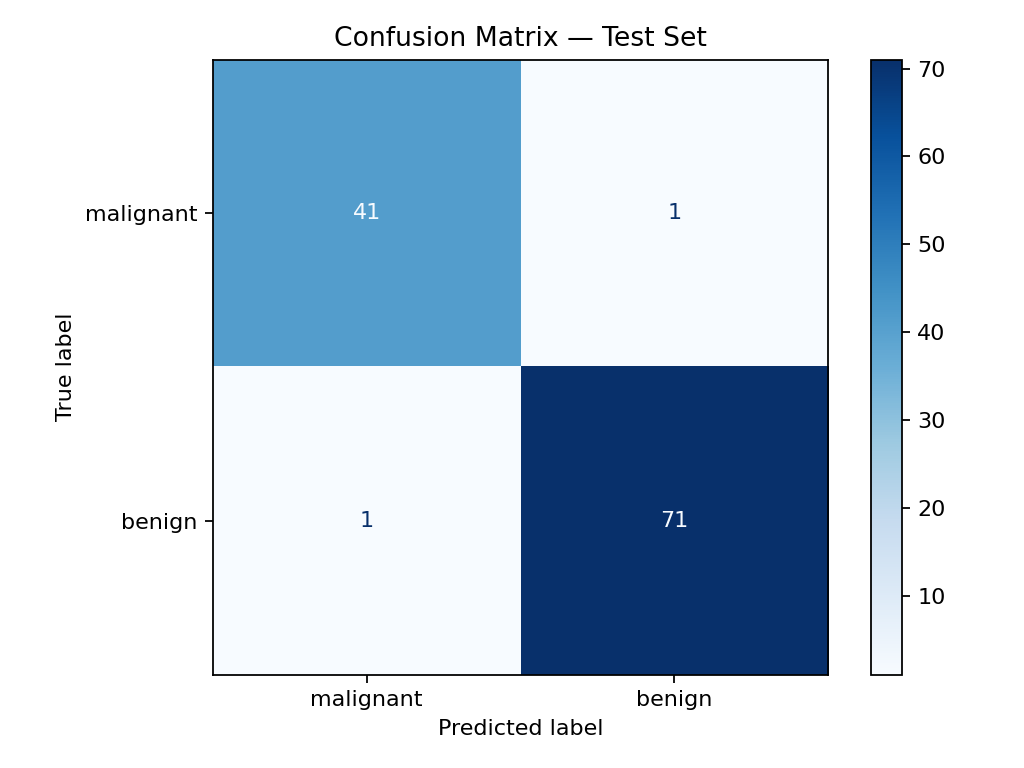

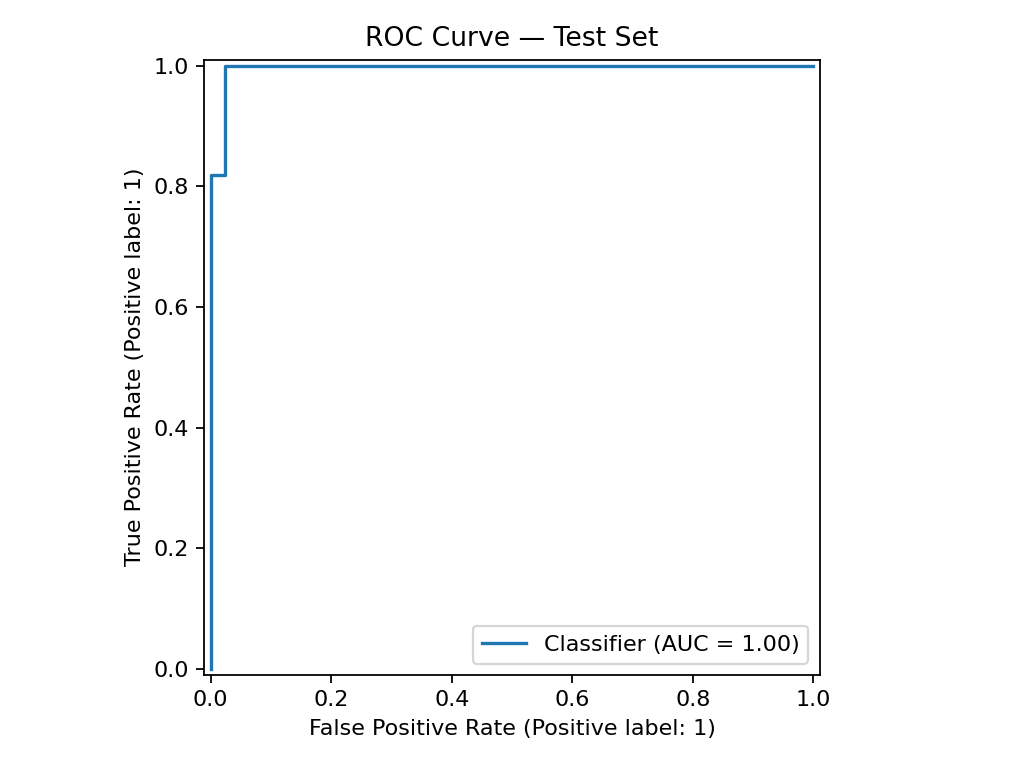

In [6]:
from IPython.display import Image, display

artifact_dir = MODEL_DIR / 'artifacts'
print('Artifacts:', sorted(path.name for path in artifact_dir.iterdir()))
display(Image(filename=str(artifact_dir / 'confusion_matrix.png')))
display(Image(filename=str(artifact_dir / 'roc_curve.png')))

## 6. Ambil screenshot

Buka [DagsHub MLflow UI](https://dagshub.com/petershaan12/SMSML-Peter-Shaan.mlflow), pilih experiment `breast-cancer-tuning`, lalu simpan:

1. `screenshoot_dashboard.jpg` dari halaman parameter dan metrik.
2. `screenshoot_artifak.jpg` dari tab artifacts yang memperlihatkan model dan `evaluation`.

Pastikan token tidak terlihat.